1️⃣ Model Evaluation (Checking Model Performance)

Important Metrics
R² Score (Coefficient of Determination)
Measures how well the model explains the data.
Value ranges from 0 to 1.
Example:


R² = 0.82
Meaning:

The model explains 82% of the variation in student grades.

Higher value = better model.

🔹 Mean Absolute Error (MAE)
Formula idea:


MAE = Average(|Actual - Predicted|)
Example:


Actual Grade = 15
Predicted Grade = 13
Error = 2
MAE tells you how many marks your prediction is wrong on average.

🔹 Mean Squared Error (MSE)
Formula idea:


MSE = Average((Actual - Predicted)²)
Large errors get more penalty, which helps detect bad predictions.

🔹 Root Mean Squared Error (RMSE)

RMSE = √MSE
RMSE is easier to understand because it is in the same unit as grades.

Example:


RMSE = 2.1
Meaning:

On average the prediction is about 2 marks off.

2️⃣ Residual Analysis

Residual = Actual Value – Predicted Value

Example:

Actual	Predicted	Residual
15	    13	        2
12	    14	        -2
18	    17	         1

3️⃣ Feature Importance

Your model uses RandomForestRegressor, which can show which features influence predictions the most.

Example result:

Feature	Importance
G2	        0.45
G1	        0.32
Studytime	0.15
Absences	0.08

4️⃣ Improving the Streamlit Web App

Your Streamlit app should be more user-friendly.

Example improvements:

Add Title

Student Performance Prediction App
Add Description
Explain what the app does.

Example:


This app predicts a student's final grade using a trained Machine Learning model.
Add Inputs
User should enter:

Study Time

Absences

G1 Grade

G2 Grade

Example UI:


Enter Student Details

Study Time: [slider]
Absences: [number]
G1 Grade: [number]
G2 Grade: [number]

Predict Final Grade
Display Prediction
Example output:


Predicted Final Grade: 14

📊 Day 9 – Model Evaluation & Visualization Code

Dataset Loaded Successfully
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
Training Data Shape: (316, 4)
Testing Data Shape: (79, 4)
Mo

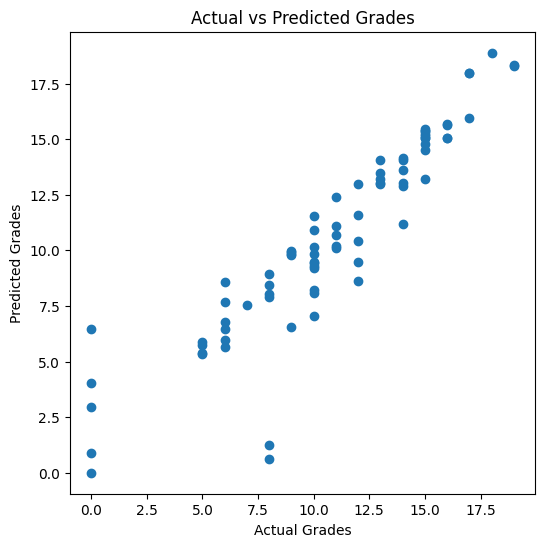

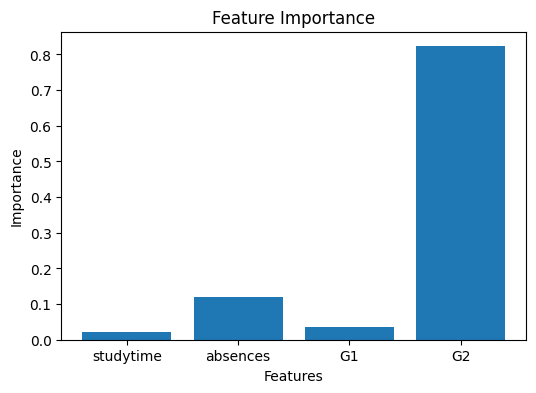


Model saved successfully in 'model/student_model.pkl'


In [3]:
# ==============================
# Day 9 - Model Evaluation & Visualization
# Student Performance Prediction
# ==============================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt


# 2️⃣ Load Dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

print("Dataset Loaded Successfully")
print(df.head())


# 3️⃣ Select Features and Target
X = df[["studytime", "absences", "G1", "G2"]]
y = df["G3"]


# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# 5️⃣ Train Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model Trained Successfully")


# 6️⃣ Make Predictions
y_pred = model.predict(X_test)


# 7️⃣ Model Evaluation

# R2 Score
r2 = r2_score(y_test, y_pred)
print("\nR2 Score:", r2)

# MAE
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)


# 8️⃣ Visualization: Actual vs Predicted

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")
plt.show()


# 9️⃣ Feature Importance

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


# 🔟 Save Model

os.makedirs("model", exist_ok=True)

with open("model/student_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("\nModel saved successfully in 'model/student_model.pkl'")